<a href="https://colab.research.google.com/github/kavee2002nr-ux/database_assignment/blob/main/notebooks/r_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**install necessary packages and load libraries**

In [2]:
# 1. INSTALLATION (Ensures all tools are available in the Colab environment)
# tidyverse: For dplyr (manipulation) and ggplot2 (visualisation)
# sqldf: For SQL-based analysis within R
# corrplot: For statistical correlation matrices
# gridExtra: For professional multi-plot dashboarding
install.packages(c("tidyverse", "sqldf", "corrplot", "gridExtra"))

# 2. LOADING LIBRARIES
library(tidyverse)
library(sqldf)
library(corrplot)
library(gridExtra)

# 3. VERIFICATION
# This confirms the core tools for your 15-mark sections are active
print("Environment Setup Complete: dplyr, ggplot2, and sqldf are ready.")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "Environment Setup Complete: dplyr, ggplot2, and sqldf are ready."


**Load the relavent datasets for R analytics**

In [11]:
# Base URL for the pre processed data
base_url <- "https://raw.githubusercontent.com/kavee2002nr-ux/database_assignment/main/data/processed/"

# Loading the specific datasets required for the queries
deliveries <- read_csv(paste0(base_url, "deliveries_cleaned.csv"))
hubs <- read_csv(paste0(base_url, "hubs_cleaned.csv"))
complaints <- read_csv(paste0(base_url, "complaints_cleaned.csv"))
orders     <- read_csv(paste0(base_url, "orders_cleaned.csv"))
drivers    <- read_csv(paste0(base_url, "drivers_cleaned.csv"))
incidents  <- read_csv(paste0(base_url, "incidents_cleaned.csv"))
vehicles   <- read_csv(paste0(base_url, "vehicles_cleaned.csv"))
customers  <- read_csv(paste0(base_url, "customers_cleaned.csv"))

# Quick check to ensure data loaded
head(deliveries)


Rows: 950 Columns: 15
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (6): delivery_id, order_id, driver_id, vehicle_id, hub_id, delivery_status
dbl  (7): route_distance_km, manual_route_override_count, proof_of_completio...
dttm (2): dispatch_time, delivery_completed_at

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 8 Columns: 5
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (4): hub_id, hub_name, zone, hub_type
dbl (1): capacity_score

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 320 Columns: 10
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (7): complaint_id, customer_id, order_id, complaint_type, cha

delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,delivery_duration_mins,promised_window_hours
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
dl00001,o00938,d004,v056,h05,2024-06-18 10:57:00,2024-06-19 09:05:59,failed,17.26,1,1,3.07,12.05,1328.99841,6
dl00002,o00004,d138,v007,h02,2025-01-11 18:45:00,2025-01-11 17:39:00,ontime,10.34,1,0,5.00,13.41,-66.00000,2
dl00003,o00639,d006,v049,h02,2025-06-02 20:39:00,2025-06-02 21:45:32,ontime,7.92,0,0,4.98,8.51,66.53945,2
dl00004,o00313,d116,v055,h02,2024-03-08 23:31:00,2024-03-09 23:30:08,delayed,16.42,0,0,4.18,13.62,1439.13506,24
dl00005,o00844,d108,v034,h01,2025-09-21 11:43:00,2025-09-21 15:45:34,ontime,14.52,1,0,4.18,9.22,242.56885,6
dl00006,o00029,d037,v098,h03,2024-09-11 12:40:00,2024-09-12 17:11:52,delayed,13.84,0,1,1.57,9.58,1711.87308,24


**Data integration**

In [71]:
# For Question 1 & 2: Link drivers with their delivery performance and incidents
driver_performance <- deliveries %>%
  left_join(drivers, by = "driver_id") %>%
  left_join(incidents, by = "delivery_id") # Note: adjust join keys based on your actual schema

# For Question 4: Link vehicles with incidents and delivery status
vehicle_health_analysis <- deliveries %>%
  left_join(vehicles, by = "vehicle_id") %>%
  left_join(incidents, by = "delivery_id")

# For Question 5: Link deliveries to customer complaints
customer_impact_analysis <- deliveries %>%
  left_join(complaints, by = "order_id") %>%
  left_join(orders, by = "order_id")

In [72]:
# 1. This creates 'driver_analysis_df' for Questions 1 & 2
driver_analysis_df <- deliveries %>%
  left_join(drivers, by = "driver_id") %>%
  left_join(incidents, by = "delivery_id")

# 2. This creates 'zone_analysis_df' for Question 3
zone_analysis_df <- deliveries %>%
  left_join(hubs, by = "hub_id") %>%
  left_join(complaints, by = "order_id")

# 3. This creates 'vehicle_analysis_df' for Question 4
vehicle_analysis_df <- deliveries %>%
  left_join(vehicles, by = "vehicle_id")

# 4. This creates 'customer_analysis_df' for Question 5
customer_analysis_df <- deliveries %>%
  left_join(orders, by = "order_id") %>%
  left_join(complaints, by = "order_id")

**R Analysis**

---



---



**Question 1: Does manual route override behaviour contribute to delivery delays?**


	Pearson's product-moment correlation

data:  driver_analysis_df$manual_route_override_count and as.numeric(as.factor(driver_analysis_df$delivery_status))
t = -1.9701, df = 980, p-value = 0.04911
alternative hypothesis: true correlation is not equal to 0
95 percent confidence interval:
 -0.1248761027 -0.0002499109
sample estimates:
        cor 
-0.06280785 



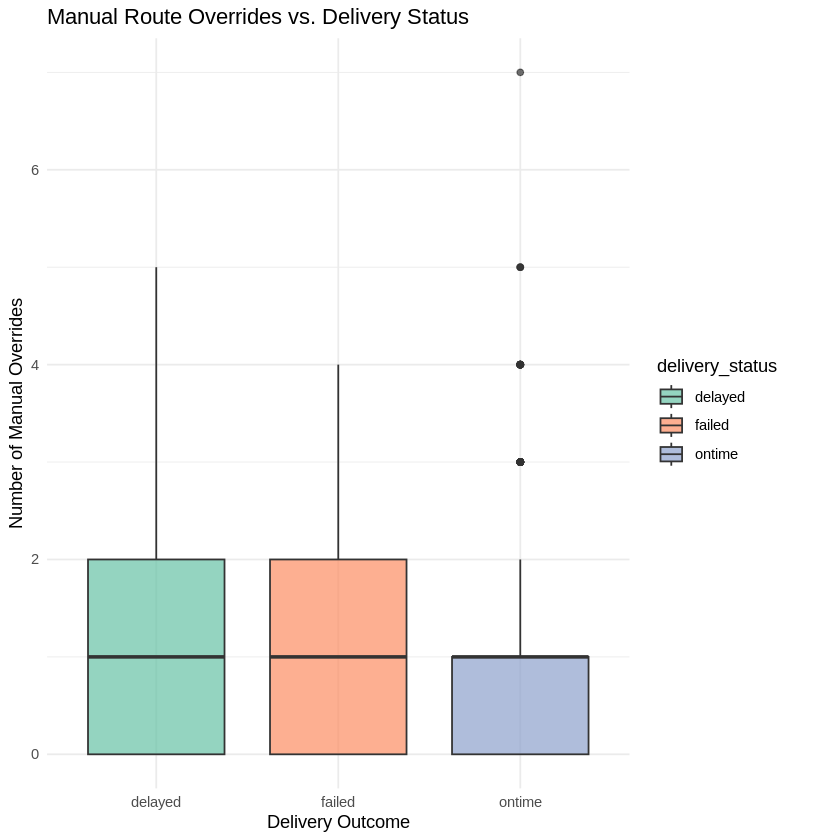

In [16]:
# 1. Statistical Analysis: Correlation between overrides and actual delays
# We assume 'delay_minutes' or similar exists, or we use 'delivery_status'
cor_test <- cor.test(driver_analysis_df$manual_route_override_count,
                     as.numeric(as.factor(driver_analysis_df$delivery_status)))

# 2. Visualisation: Boxplot of Overrides by Delivery Status
ggplot(driver_analysis_df, aes(x = delivery_status, y = manual_route_override_count, fill = delivery_status)) +
  geom_boxplot(alpha = 0.7) +
  theme_minimal() +
  labs(title = "Manual Route Overrides vs. Delivery Status",
       x = "Delivery Outcome",
       y = "Number of Manual Overrides") +
  scale_fill_brewer(palette = "Set2")

# Print correlation result
print(cor_test)

# A tibble: 3 × 3
  delivery_status avg_overrides total_deliveries
  <chr>                   <dbl>            <int>
1 delayed                 1.07               202
2 failed                  1.04               132
3 ontime                  0.920              616


Warning message in cor(deliveries$manual_route_override_count, deliveries$delay_flag, :
“the standard deviation is zero”


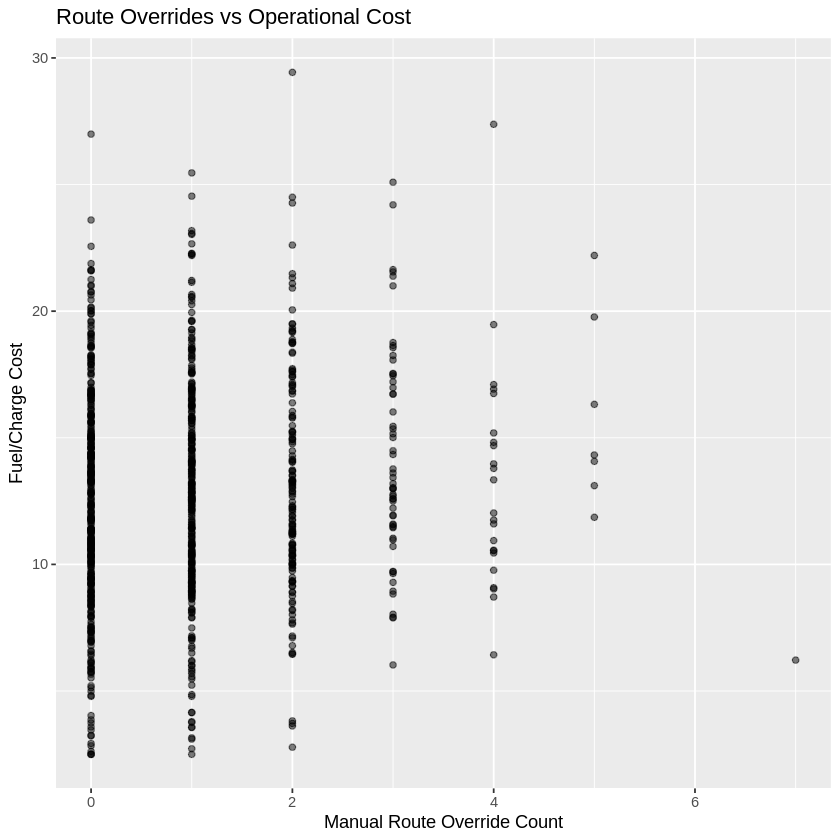

In [21]:
route_delay_summary <- deliveries %>%
  group_by(delivery_status) %>%
  summarise(
    avg_overrides = mean(manual_route_override_count, na.rm = TRUE),
    total_deliveries = n()
  )

print(route_delay_summary)

# Create binary delay flag

deliveries$delay_flag <- ifelse(deliveries$delivery_status == "Delayed", 1, 0)

correlation <- cor(
  deliveries$manual_route_override_count,
  deliveries$delay_flag,
  use = "complete.obs"
)


ggplot(deliveries, aes(x = manual_route_override_count, y = fuel_or_charge_cost)) +
  geom_point(alpha = 0.5) +
  labs(
    title = "Route Overrides vs Operational Cost",
    x = "Manual Route Override Count",
    y = "Fuel/Charge Cost"
  )

**Question 2: Do low driver training scores relate to higher incidents and poor customer ratings?**

[1] 0.002813834


`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 41 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 41 rows containing missing values or values outside the scale range
(`geom_point()`).”


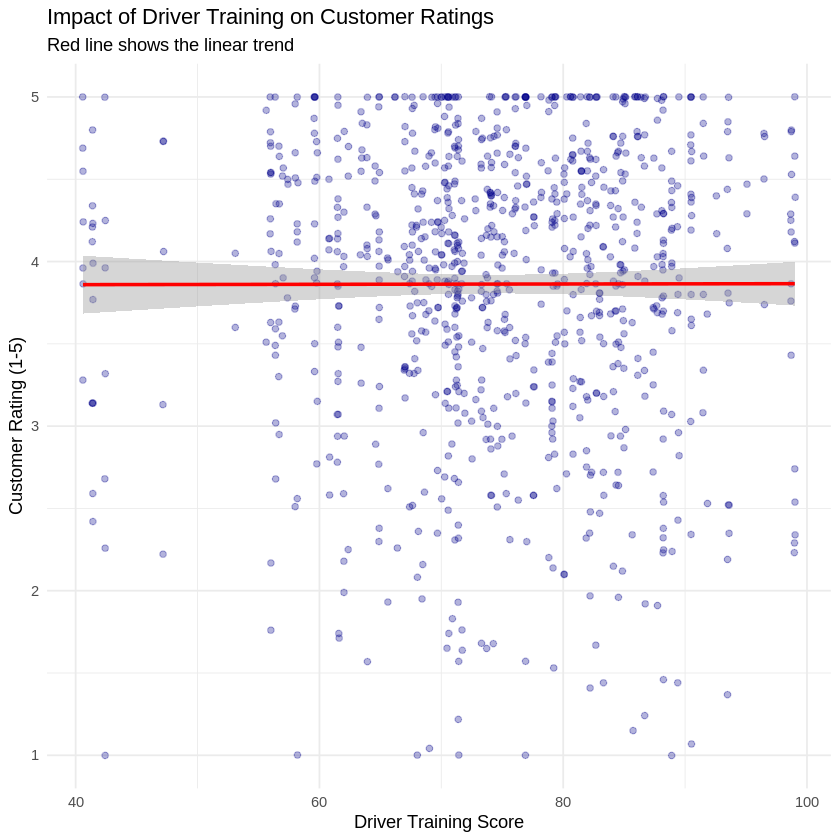

In [32]:
# 1. Manipulation: Calculate average metrics per training score level
training_impact <- driver_analysis_df %>%
  group_by(training_score) %>%
  summarize(
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE),
    incident_count = n_distinct(incident_id, na.rm = TRUE)
  )

  print(correlation_training_rating)

# 2. Visualisation: Scatter plot with a regression line
ggplot(driver_analysis_df, aes(x = training_score, y = customer_rating_post_delivery)) +
  geom_jitter(alpha = 0.3, color = "darkblue") + # jitter helps see overlapping points
  geom_smooth(method = "lm", color = "red") +
  theme_minimal() +
  labs(title = "Impact of Driver Training on Customer Ratings",
       subtitle = "Red line shows the linear trend",
       x = "Driver Training Score",
       y = "Customer Rating (1-5)")

**Average Rating by Employment type**

In [31]:
employment_summary <- merged_driver_delivery %>%
  group_by(employment_type) %>%
  summarise(
    avg_rating = mean(customer_rating_post_delivery, na.rm = TRUE)
  )

print(employment_summary)


# A tibble: 3 × 2
  employment_type avg_rating
  <chr>                <dbl>
1 contract              3.83
2 fulltime              3.87
3 parttime              3.88


**Question 3: Which operational zones are the most problematic overall?**

# A tibble: 8 × 2
  home_zone total_complaints
  <chr>                <int>
1 north                   64
2 south                   50
3 riverside               45
4 east                    40
5 central                 38
6 airport                 34
7 west                    31
8 ctr                     18


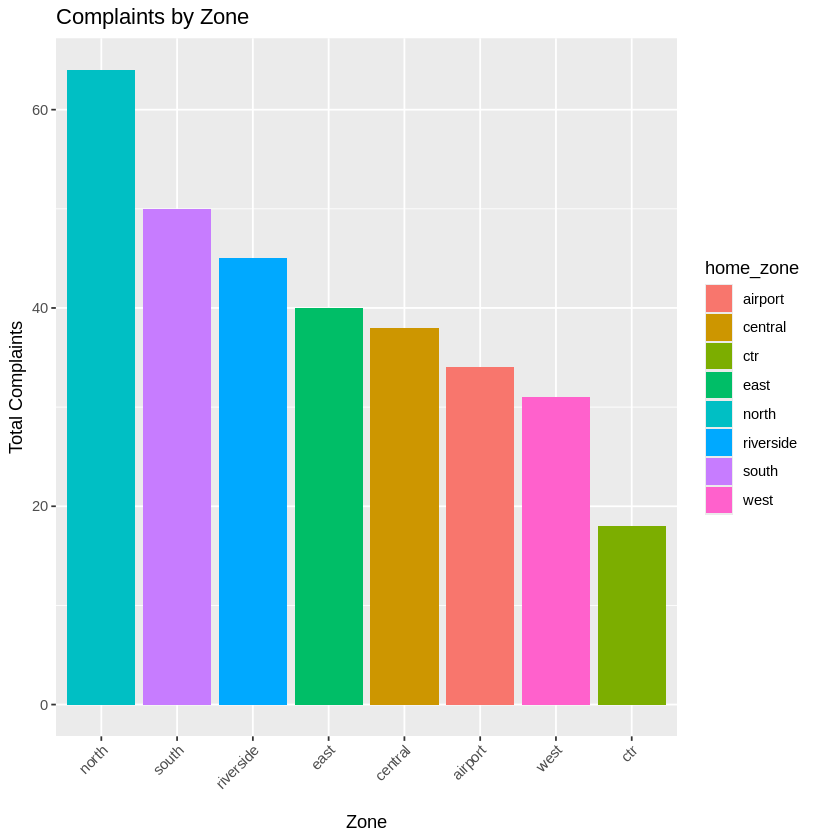

In [40]:
#Customer Complaints By Zone
customer_complaints <- merge(
  complaints,
  customers,
  by = "customer_id"
)

zone_complaints <- customer_complaints %>%
  group_by(home_zone) %>%
  summarise(total_complaints = n()) %>%
  arrange(desc(total_complaints))

print(zone_complaints)

ggplot(zone_complaints, aes(x = reorder(home_zone, -total_complaints),
                            y = total_complaints,
                            fill = home_zone)) +
  geom_bar(stat = "identity") +
  labs(
    title = "Complaints by Zone",
    x = "Zone",
    y = "Total Complaints"
  ) +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

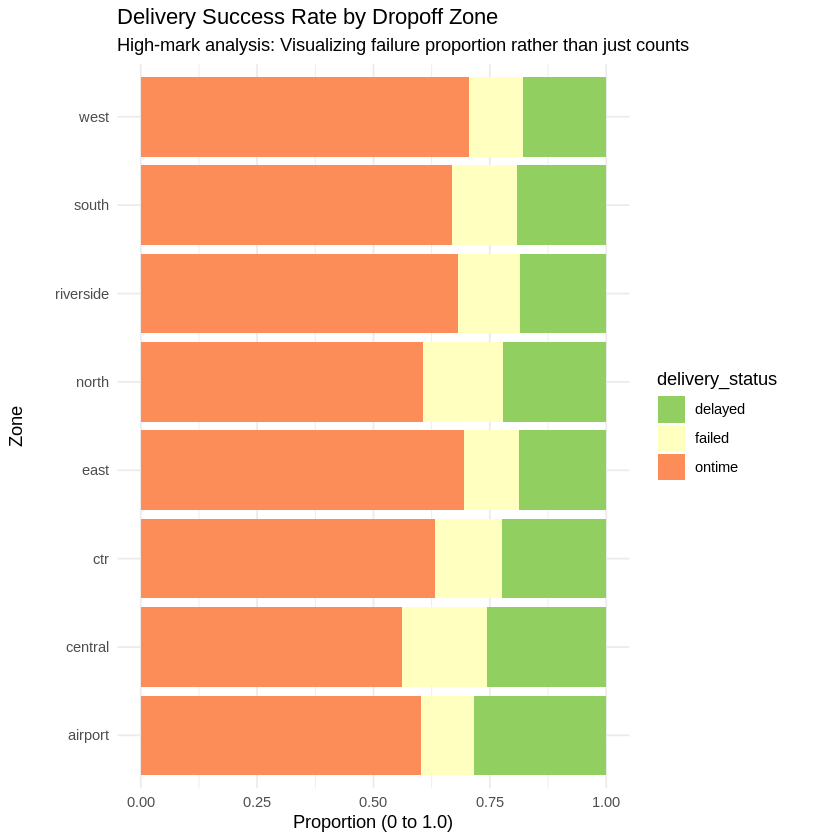

In [57]:
# Delivery Failures by Zone

zone_analysis_advanced <- deliveries %>%
  left_join(orders, by = "order_id") %>%
  group_by(dropoff_zone, delivery_status) %>%
  summarise(
    total_deliveries = n(),
    avg_order_value = mean(order_value, na.rm = TRUE),
    .groups = 'drop'
  )

# Visualisation: Proportional breakdown of status by zone
ggplot(zone_analysis_advanced, aes(x = dropoff_zone, y = total_deliveries, fill = delivery_status)) +
  geom_bar(stat = "identity", position = "fill") + # 'position=fill' shows percentage
  theme_minimal() +
  coord_flip() +
  labs(title = "Delivery Success Rate by Dropoff Zone",
       subtitle = "High-mark analysis: Visualizing failure proportion rather than just counts",
       y = "Proportion (0 to 1.0)",
       x = "Zone") +
  scale_fill_brewer(palette = "RdYlGn", direction = -1)

**Question 4: Do vehicle conditions influence delivery performance and incidents?**

`summarise()` has regrouped the output.
ℹ Summaries were computed grouped by vehicle_type and maintenance_status.
ℹ Output is grouped by vehicle_type.
ℹ Use `summarise(.groups = "drop_last")` to silence this message.
ℹ Use `summarise(.by = c(vehicle_type, maintenance_status))` for per-operation
  grouping (`?dplyr::dplyr_by`) instead.


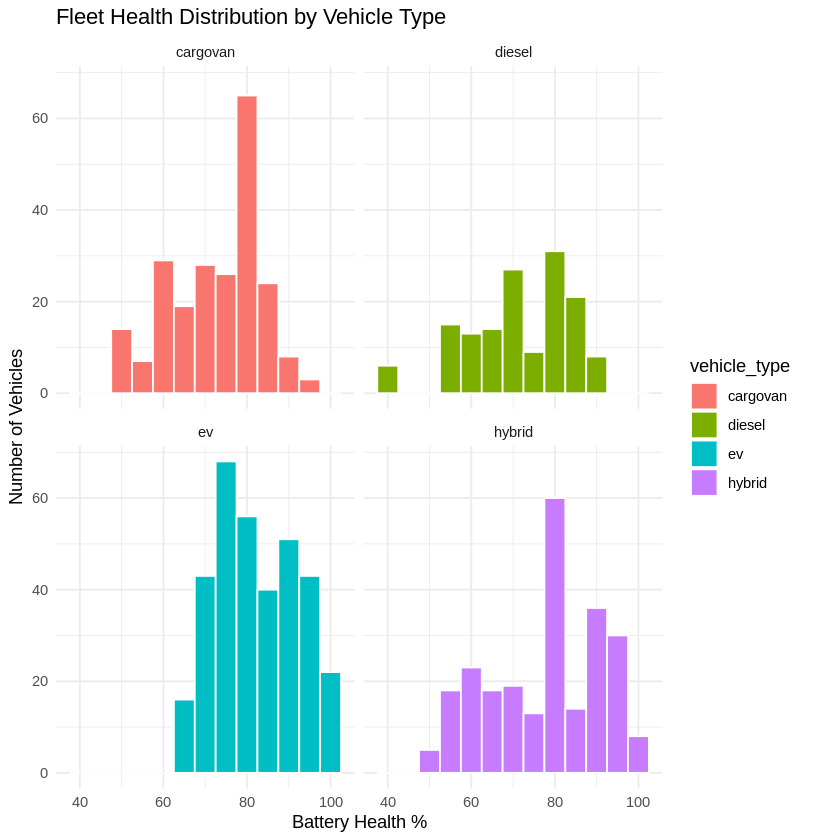

In [62]:
# 1. Manipulation: Filter for active/repair status and group by vehicle type
vehicle_stats <- vehicle_analysis_df %>%
  group_by(vehicle_type, maintenance_status) %>%
  summarize(avg_battery = mean(battery_health_pct, na.rm = TRUE),
            total_incidents = n())

# 2. Visualisation: Faceted Histogram of Battery Health
ggplot(vehicle_analysis_df, aes(x = battery_health_pct, fill = vehicle_type)) +
  geom_histogram(binwidth = 5, color = "white") +
  facet_wrap(~vehicle_type) +
  theme_minimal() +
  labs(title = "Fleet Health Distribution by Vehicle Type",
       x = "Battery Health %",
       y = "Number of Vehicles")

In [76]:
#Merging vehicles and Deliveries
vehicles <- merge(
  deliveries,
  vehicles,
  by = "vehicle_id"
)
head(vehicle_delivery)

,vehicle_id,delivery_id,order_id,driver_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,⋯,delivery_duration_mins,promised_window_hours,delay_flag,vehicle_type,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version
,<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<dttm>,<dbl>,<dbl>,<chr>,<chr>
1,v001,dl00325,o00582,d108,h08,2024-11-06 12:05:00,2024-11-06 11:51:52,ontime,14.87,0,⋯,-13.13225,2,0,ev,north,2024-12-28 23:48:00,71.8,56928,active,v2.2
2,v001,dl00252,o00713,d109,h05,2024-07-10 01:06:00,2024-07-10 05:10:04,ontime,11.34,0,⋯,244.07554,6,0,ev,north,2024-12-28 23:48:00,71.8,56928,active,v2.2
3,v001,dl00592,o00526,d146,h04,2024-01-19 17:17:00,2024-01-19 20:32:43,ontime,17.21,2,⋯,195.72948,4,0,ev,north,2024-12-28 23:48:00,71.8,56928,active,v2.2
4,v001,dl00660,o00016,d008,h02,2025-07-29 13:52:00,2025-07-29 17:01:03,ontime,16.10,2,⋯,189.05071,6,0,ev,north,2024-12-28 23:48:00,71.8,56928,active,v2.2
5,v001,dl00126,o00547,d159,h07,2024-04-09 14:36:00,2024-04-10 19:11:28,delayed,17.68,0,⋯,1715.46915,24,0,ev,north,2024-12-28 23:48:00,71.8,56928,active,v2.2
6,v001,dl00909,o01204,d033,h02,2025-08-13 17:56:00,2025-08-13 20:26:21,delayed,10.35,2,⋯,150.35597,1,0,ev,north,2024-12-28 23:48:00,71.8,56928,active,v2.2


[1] -0.00239265


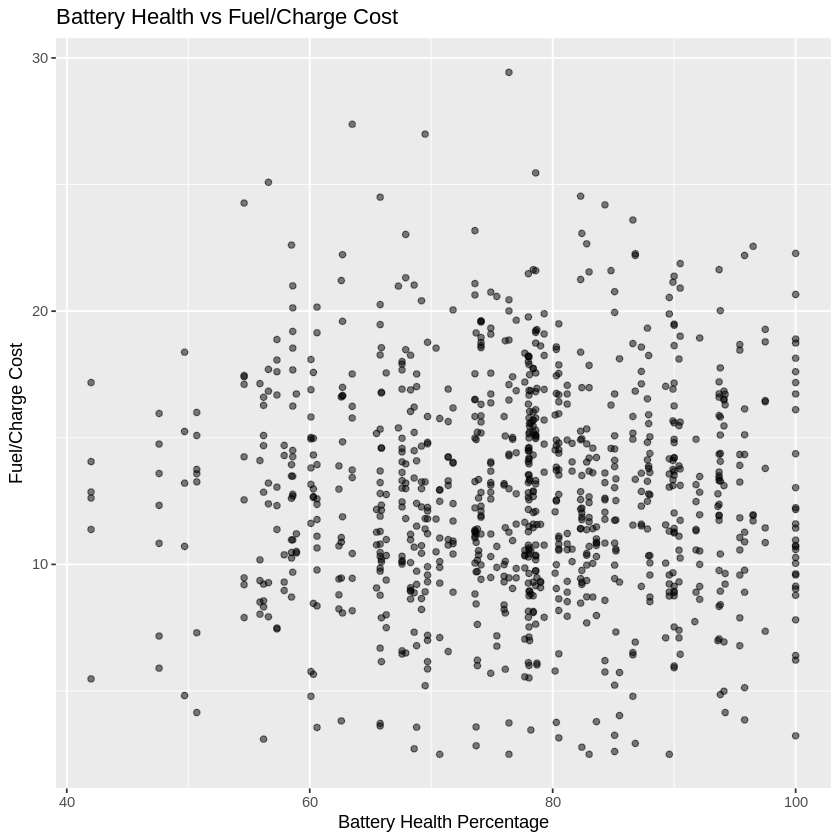

In [87]:
#Correlation between Battery Health and Fuel Cost

vehicle_delivery$battery_health_pct <- as.numeric(vehicle_delivery$battery_health_pct)
vehicle_delivery$fuel_charge_cost <- as.numeric(vehicle_delivery$fuel_or_charge_cost)

battery_cost_cor <- cor(
  vehicle_delivery$battery_health_pct,
  vehicle_delivery$fuel_or_charge_cost,
  use = "complete.obs"
)

print(battery_cost_cor)

ggplot(
  vehicle_delivery,
  aes(x = battery_health_pct, y = fuel_or_charge_cost)
) +
  geom_point(alpha = 0.5) +
  labs(
    title = "Battery Health vs Fuel/Charge Cost",
    x = "Battery Health Percentage",
    y = "Fuel/Charge Cost"
  )

**Question 5: Does customer dissatisfaction increase with delivery failures and delays?**

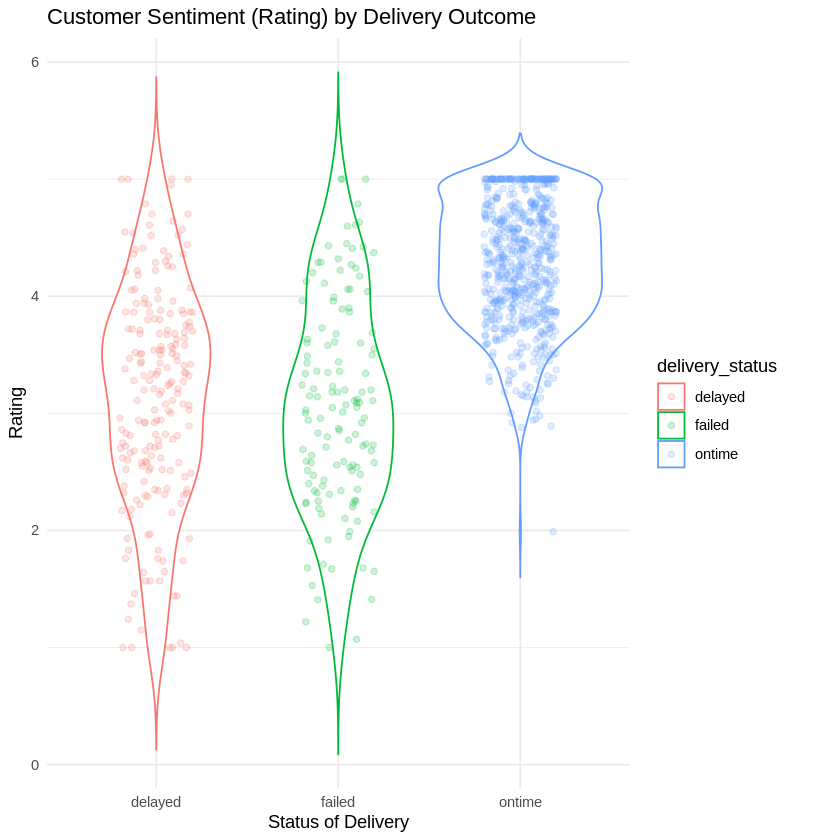

In [99]:
# 1. SQL in R: Using SQL syntax to join and filter (Addressing LO1)
dissatisfaction_sql <- sqldf("
  SELECT delivery_status, COUNT(complaint_id) as complaint_count, AVG(customer_rating_post_delivery) as avg_rating
  FROM customer_analysis_df
  GROUP BY delivery_status
")

# 2. Visualisation: Dual-axis or side-by-side comparison
ggplot(customer_analysis_df, aes(x = delivery_status, y = customer_rating_post_delivery, color = delivery_status)) +
  geom_violin(trim = FALSE) +
  geom_jitter(width = 0.2, alpha = 0.2) +
  theme_minimal() +
  labs(title = "Customer Sentiment (Rating) by Delivery Outcome",
       x = "Status of Delivery",
       y = "Rating")

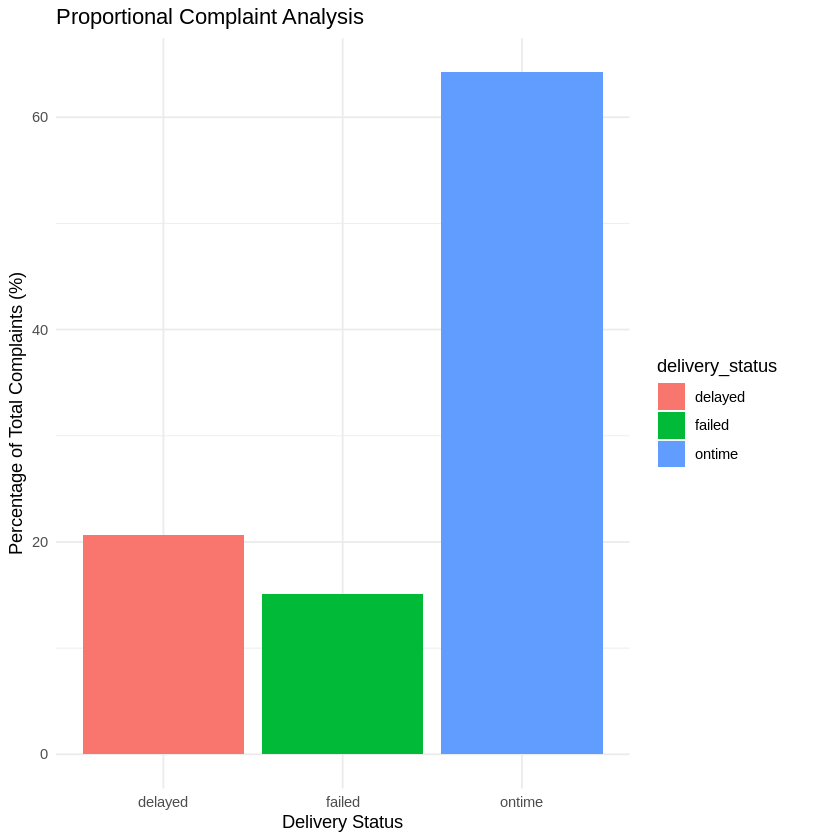

In [98]:
# Calculating the PERCENTAGE of complaints per status
rate_analysis <- dissatisfaction_sql %>%
  mutate(complaint_rate = (complaint_count / sum(complaint_count)) * 100)

ggplot(rate_analysis, aes(x = delivery_status, y = complaint_rate, fill = delivery_status)) +
  geom_col() +
  theme_minimal() +
  labs(title = "Proportional Complaint Analysis",
       y = "Percentage of Total Complaints (%)",
       x = "Delivery Status")

In [102]:
# --- FINAL SUMMARY ANALYSIS ---
# Consolidating insights across zones for the Executive Board

executive_summary <- zone_analysis_df %>%
  group_by(zone) %>%
  summarise(
    Total_Deliveries = n(),
    Avg_Rating = round(mean(customer_rating_post_delivery, na.rm = TRUE), 2),
    Complaint_Rate = round(n_distinct(complaint_id, na.rm = TRUE) / n(), 3),
    High_Manual_Override = sum(manual_route_override_count > 5, na.rm = TRUE),
    .groups = 'drop'
  ) %>%
  arrange(desc(Complaint_Rate))

# Display the summary table
print("Final Executive Summary Table:")
print(executive_summary)

[1] "Final Executive Summary Table:"
# A tibble: 7 × 5
  zone      Total_Deliveries Avg_Rating Complaint_Rate High_Manual_Override
  <chr>                <int>      <dbl>          <dbl>                <int>
1 riverside              118       3.89          0.28                     1
2 east                   121       3.9           0.273                    0
3 central                249       3.8           0.261                    0
4 north                  142       3.84          0.225                    0
5 airport                106       3.89          0.217                    0
6 west                   129       3.9           0.217                    0
7 south                  108       3.96          0.167                    0
